In [1]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.9'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
# platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
# jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')

import matplotlib

import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')

import dill as dill

# probes_forecast = ['ky','kk', 'gg', 'gy', 'gk' ,'ge']
# sc_val = 500
%load_ext autoreload
%autoreload 2


1 1


/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

from scipy.interpolate import interp1d
zedges = np.array([0.4, 0.6, 0.8,1.1])
nz_lrg_all = np.loadtxt(abs_path_data + '/pge/desi_lrg_nz.txt')
# nz_lrg_all.shape
zv, nzv = nz_lrg_all[:,0], nz_lrg_all[:,1]


nbins_lens = len(zedges) - 1
zarray_lens = np.linspace(0.001, 1.6, 100)
nz_interp = interp1d(zv, nzv, fill_value=1e-10, bounds_error=False)
nz_zarray = nz_interp(zarray_lens)
nz_lens = {}
for jb in range(nbins_lens):
    nz_jb = np.zeros_like(nz_zarray)
    indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb+1]))[0]
    nz_jb[indsel] = nz_zarray[indsel]
    norm_val = np.trapz(nz_jb, zarray_lens)
    nz_jb = nz_jb/norm_val
    nz_lens[jb] = nz_jb

df_nz_comoving = np.loadtxt('/mnt/home/spandey/ceph/GODMAX/data/pge/desi_lrg_comoving_density.txt')
    
zarray_comoving = df_nz_comoving[:,0]
nz_comoving = df_nz_comoving[:,1]




In [18]:

# cosmo_params_dict = {'flat': True, 'H0': 70.0, 'Om0': 0.2793, 'Ob0': 0.0463, 'sigma8': 0.821, 'ns': 0.972, 'w0':-1.0}
# cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8': 0.81, 'ns': 0.95, 'w0':-1.0}
cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.3136, 'Ob0': 0.0491, 'sigma8': 0.8416941, 'ns': 0.9645, 'w0':-1.0}
# cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.29, 'Ob0': 0.049, 'sigma8': 0.783, 'ns': 0.95, 'w0':-1.0}
sim_params_dict = {}
sim_params_dict['nfw_trunc'] = True
sim_params_dict['gamma_rhogas'] = 2.0
sim_params_dict['delta_rhogas'] = 7.0
# sim_params_dict['theta_co'] = 0.01
# sim_params_dict['theta_ej'] = 1.0

sim_params_dict['theta_co_0'] = 0.01
sim_params_dict['log10_Mstar0_theta_co'] = 15.0
sim_params_dict['nu_theta_co_M'] = 0.0
sim_params_dict['nu_theta_co_z'] = 0.0

sim_params_dict['theta_ej_0'] = 2.75
sim_params_dict['log10_Mstar0_theta_ej'] = 15.0
sim_params_dict['nu_theta_ej_M'] = 0.0
sim_params_dict['nu_theta_ej_z'] = 0.0

sim_params_dict['log10_Mc0'] = 14.0
sim_params_dict['log10_Mstar0'] = 14.0
sim_params_dict['mu_beta'] = 1.1
sim_params_dict['nu_z'] = -0.2
sim_params_dict['nu_M'] = 0.0

sim_params_dict['eta_star'] = 0.3
sim_params_dict['eta_cga'] = 0.6


sim_params_dict['neg_bhse_plus_1'] = 0.833
sim_params_dict['A_starcga'] = 0.09
sim_params_dict['log10_M1_starcga'] = 11.4
sim_params_dict['epsilon_rt'] = 4.0


sim_params_dict['a_zeta'] = 0.3
sim_params_dict['n_zeta'] = 2
sim_params_dict['alpha_nt'] = 0.18
sim_params_dict['beta_nt'] = 0.5
sim_params_dict['n_nt'] = 0.3
sim_params_dict['cosmo'] = cosmo_params_dict

sim_params_dict['log10M1_fshmr'] = 12.35
sim_params_dict['log10Mstar0_fshmr'] = 10.72
sim_params_dict['beta_fshmr'] = 0.44
sim_params_dict['delta_fshmr'] = 0.57
sim_params_dict['gamma_fshmr'] = 1.56
sim_params_dict['Bcut_Nsat'] = 1.69
sim_params_dict['Bsat_Nsat'] = 9.01
sim_params_dict['betacut_Nsat'] = 0.6
sim_params_dict['betasat_Nsat'] = 0.74
sim_params_dict['alphasat_Nsat'] = 1.0
sim_params_dict['siglogMstar_Ncen'] = 0.25
sim_params_dict['nbar_gal_comoving_zarray'] = zarray_comoving
sim_params_dict['nbar_gal_comoving_val'] = nz_comoving


halo_params_dict = {}
halo_params_dict['rmin'], halo_params_dict['rmax'], halo_params_dict['nr'] = 5e-3, 8, 32
halo_params_dict['zmin'], halo_params_dict['zmax'], halo_params_dict['nz'] = 0.01, 2.0, 22
halo_params_dict['lg10_Mmin'], halo_params_dict['lg10_Mmax'], halo_params_dict['nM'] = 11.0, 16.0, 24

lmin = 10.0
lmax = 11000.0
fac = 1
dl_log_array = 0.23025851 / fac
# dl_log_array = 0.1
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
halo_params_dict['nell'] = len(l_array_survey)
halo_params_dict['ellmin'] = l_array_survey[0]
halo_params_dict['ellmax'] = l_array_survey[-1]
# halo_params_dict['ellmin'], halo_params_dict['ellmax'], halo_params_dict['nell'] = 8, 2**14, 32
# try:
halo_params_dict['sig_logc_z_array'] = np.ones(halo_params_dict['nz']) * 0.05
halo_params_dict['mdef'] = '200c'
halo_params_dict['hmf_model'] = 'T10'
# halo_params_dict['conc_model'] = 'Diemer15'
halo_params_dict['conc_model'] = 'Duffy08'
halo_params_dict['do_corr_2h_mm'] = True

# halo_params_dict['do_corr_2h_mm'] = False
analysis_dict = {}

from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 5
nz_info_dict['nz0'] = np.maximum(df['nz_source'].data['BIN1'], 1e-4)
nz_info_dict['nz1'] = np.maximum(df['nz_source'].data['BIN2'], 1e-4)
nz_info_dict['nz2'] = np.maximum(df['nz_source'].data['BIN3'], 1e-4)
nz_info_dict['nz3'] = np.maximum(df['nz_source'].data['BIN4'], 1e-4)
nz_info_dict['nz4'] = np.maximum(df['nz_source'].data['BIN5'], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict

nz_info_dict = {}
nz_info_dict['z_array_lens'] = zarray_lens
nz_info_dict['nbins_lens'] = 3
nz_info_dict['nz0'] = np.maximum(nz_lens[0], 1e-4)
nz_info_dict['nz1'] = np.maximum(nz_lens[1], 1e-4)
nz_info_dict['nz2'] = np.maximum(nz_lens[2], 1e-4)
analysis_dict['nz_lens_info_dict'] = nz_info_dict

analysis_dict['zmin_pk'] = 0.01
analysis_dict['zmax_pk'] = 1.5
analysis_dict['nz_pk'] = 128

analysis_dict['do_ky'] = True
analysis_dict['do_kk'] = True
analysis_dict['do_gy'] = True
analysis_dict['do_gk'] = True
analysis_dict['do_gg'] = True
analysis_dict['do_ge'] = True

analysis_dict['fsky_yy'] = 0.4
analysis_dict['fsky_ky'] = 18000/41253
analysis_dict['fsky_kk'] = 18000/41253
analysis_dict['fsky_yg'] = (14000/41253)
analysis_dict['fsky_kg'] = 0.1
analysis_dict['fsky_gg'] = (14000/41253)

analysis_dict['fac_ell_hres'] = fac

# df_data = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits')
# df_data = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits')
theta_data = df['xip'].data['ANG'][0:20]

# analysis_dict['ellmin_transf'], analysis_dict['ellmax_transf'], analysis_dict['nell_transf'] = 8, 2**15, 16384
analysis_dict['angles_data_array'] = jnp.array(theta_data)
analysis_dict['beam_fwhm_arcmin'] = 1.4
analysis_dict['want_like_diff'] = True
analysis_dict['calc_nfw_only'] = False
analysis_dict['conc_dep_model'] = False


analysis_dict['get_cov'] = True
analysis_dict['stats_for_cov'] = ['ky', 'kk', 'gy', 'gg', 'gk']
analysis_dict['analysis_coords'] = 'fourier'
# l_array_survey = np.logspace(np.log10(lmin), np.log10(lmax), int((lmax-lmin)/dl_log_array)+1)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)

ks = np.geomspace(5e-2,50,15) # wavenumbers
analysis_dict['k_array_survey'] = jnp.array(ks)

analysis_dict['dl_array_survey'] = jnp.array(dl_array)
# analysis_dict['yy_total_ell_fname'] = '/Users/shivam/Downloads/ACT_Cls/Cls_ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy_apod10arcmin_21Mar24.txt'
# analysis_dict['yy_total_ell_fname'] = '/Users/shivam/Downloads/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt'
# analysis_dict['yy_total_ell_fname'] = os.path.abspath(abs_path_data + '/DESxACT/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt')
analysis_dict['yy_total_ell_fname'] = os.path.abspath(abs_path_data + '/pge/Noise_fid_yy_beamed_1p4arcmin.txt')

analysis_dict['sigma_epsilon_SN_bins'] = [0.367, 0.367, 0.367, 0.367, 0.367]
analysis_dict['neff_arcmin2_SN_bins'] = [2.24,2.24,2.24,2.24,2.24]

Ngals_bins = 3.33*np.array([506905, 771875, 859824])
analysis_dict['nbar_lens_bins'] = Ngals_bins/(analysis_dict['fsky_gg']*41253*(60**2))

other_params_dict = {}
other_params_dict['A_IA'] = 0.5
other_params_dict['eta_IA'] = 0.1
other_params_dict['z0_IA'] = 0.62
other_params_dict['C1_rhocrit'] = 0.0134
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])





In [19]:
import pickle as pk

df = pk.load(open(abs_path_data + '/pge/DV_fid_Cl_Pk_cov_mthresh_hod.pk', 'rb'))
probes_all = df['probes']
ell_edges_left = df['edges_left']
ell_edges_right = df['edges_right']
ell_array = df['ell_array']
k_array = df['k_array']
cov_total = df['cov_mat']
Cl_total = df['Cl_Pk']
bin_comb_all_wprobe = df['bin_comb_all_wprobe']




In [20]:


# import copy
# from tqdm import tqdm
# from get_power_spectra import get_power_BCMP
# get_power_BCMP_test = get_power_BCMP(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, verbose_time=False)

# nell = len(ell_array)
# nk = len(analysis_dict['k_array_survey'])
# Cl_all = jnp.zeros((cov_total.shape[0]))
# for jp1 in range(len(bin_comb_all_wprobe)):
#     binwprobe1 = bin_comb_all_wprobe[jp1]
#     probe1 = binwprobe1[0]
#     bin_comb1 = binwprobe1[1]
#     b1, b2 = bin_comb1[0], bin_comb1[1]
#     if probe1 == 'ky':
#         Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[b1-1,:])
#     if probe1 == 'kk':
#         Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_tot_mat[b1-1,b2-1,:])
#     if probe1 == 'gg':
#         Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[b1-1,b2-1,:])
#     if probe1 == 'gk':
#         Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_tot_mat[b1-1,b2-1,:])
#     if probe1 == 'gy':
#         Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[b1-1,:])

# edge_left_pge = ell_edges_left[-1]
# Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
# Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
# Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])




In [21]:
import copy
from tqdm import tqdm
from get_power_spectra import get_power_BCMP
sim_params_dict_vary = copy.deepcopy(sim_params_dict)
other_params_dict_vary = copy.deepcopy(other_params_dict)
analysis_dict_vary = copy.deepcopy(analysis_dict)
analysis_dict_vary['calc_nfw_only'] = True
get_power_BCMP_test = get_power_BCMP(sim_params_dict_vary, halo_params_dict, analysis_dict_vary, other_params_dict_vary, verbose_time=False)

nell = len(ell_array)
nk = len(analysis_dict['k_array_survey'])
Cl_all_nfw = jnp.zeros((2*nell + nk))
jc = 0
for jp1 in range(len(bin_comb_all_wprobe)):
    binwprobe1 = bin_comb_all_wprobe[jp1]
    probe1 = binwprobe1[0]
    bin_comb1 = binwprobe1[1]
    b1, b2 = bin_comb1[0], bin_comb1[1]
    if probe1 == 'kk':
        if b1 == 3 and b2 == 3:
            Cl_all_nfw = Cl_all_nfw.at[0*nell:(1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_nfw_tot_mat[b1-1,b2-1,:])
    if probe1 == 'gk':
        if b1 == 1 and b2 == 3:
            Cl_all_nfw = Cl_all_nfw.at[nell:(2)*nell].set(get_power_BCMP_test.Cl_gal_kappa_nfw_tot_mat[b1-1,b2-1,:])

edge_left_pge = 2*nell
Cl_all_nfw = Cl_all_nfw.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])



In [22]:
import copy
from tqdm import tqdm
from get_power_spectra import get_power_BCMP
sim_params_dict_vary = copy.deepcopy(sim_params_dict)
other_params_dict_vary = copy.deepcopy(other_params_dict)
analysis_dict_vary = copy.deepcopy(analysis_dict)
# analysis_dict_vary['calc_nfw_only'] = True
get_power_BCMP_test = get_power_BCMP(sim_params_dict_vary, halo_params_dict, analysis_dict_vary, other_params_dict_vary, verbose_time=False)

nell = len(ell_array)
nk = len(analysis_dict['k_array_survey'])
Cl_all = jnp.zeros((2*nell + nk))
jc = 0
for jp1 in range(len(bin_comb_all_wprobe)):
    binwprobe1 = bin_comb_all_wprobe[jp1]
    probe1 = binwprobe1[0]
    bin_comb1 = binwprobe1[1]
    b1, b2 = bin_comb1[0], bin_comb1[1]
    if probe1 == 'kk':
        if b1 == 3 and b2 == 3:
            Cl_all = Cl_all.at[0*nell:(1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_tot_mat[b1-1,b2-1,:])
    if probe1 == 'gk':
        if b1 == 1 and b2 == 3:
            Cl_all = Cl_all.at[nell:(2)*nell].set(get_power_BCMP_test.Cl_gal_kappa_tot_mat[b1-1,b2-1,:])

edge_left_pge = 2*nell
Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])

Cl_all_fid = jnp.array(Cl_all)


In [23]:
Cl_all_fid/Cl_all_nfw



Array([0.99228866, 0.99218043, 0.99216333, 0.99223715, 0.99233505,
       0.99251753, 0.99184147, 0.99278095, 0.99307133, 0.99301255,
       0.99473476, 0.99638342, 0.99960436, 1.00413604, 1.00909416,
       1.0129622 , 1.01463098, 1.01285781, 1.00704632, 0.99676522,
       0.98195321, 0.96299595, 0.94040576, 0.91542246, 0.88917356,
       0.8636013 , 0.83973253, 0.81947859, 0.80310603, 0.79138111,
       0.9924257 , 0.99240099, 0.99238205, 0.99236903, 0.99236462,
       0.9923747 , 0.9924091 , 0.99247269, 0.99255033, 0.99262257,
       0.99282203, 0.99249816, 0.99021733, 0.98929584, 0.9903917 ,
       0.99112195, 0.99250514, 0.99371055, 0.99454308, 0.99400827,
       0.99131741, 0.98557052, 0.97618182, 0.96329233, 0.94742463,
       0.92985544, 0.9118114 , 0.89442465, 0.87798454, 0.86306096,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        ,        

In [24]:
import jax 
from tqdm import tqdm

# @jax.jit
def get_mean_sims(p):
    sim_params_dict_vary = copy.deepcopy(sim_params_dict)
    other_params_dict_vary = copy.deepcopy(other_params_dict)

    for jp in range(len(sim_param_vary_names)):
        sim_params_dict_vary[sim_param_vary_names[jp]] = p[jp]
    get_power_BCMP_test = get_power_BCMP(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary, verbose_time=False)

    nell = len(ell_array)
    nk = len(analysis_dict['k_array_survey'])
    Cl_all = jnp.zeros((2*nell + nk))
    jc = 0
    for jp1 in range(len(bin_comb_all_wprobe)):
        binwprobe1 = bin_comb_all_wprobe[jp1]
        probe1 = binwprobe1[0]
        bin_comb1 = binwprobe1[1]
        b1, b2 = bin_comb1[0], bin_comb1[1]
        if probe1 == 'kk':
            if b1 == 3 and b2 == 3:
                Cl_all = Cl_all.at[0*nell:(1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_tot_mat[b1-1,b2-1,:])
        if probe1 == 'gk':
            if b1 == 1 and b2 == 3:
                Cl_all = Cl_all.at[nell:(2)*nell].set(get_power_BCMP_test.Cl_gal_kappa_tot_mat[b1-1,b2-1,:])

    edge_left_pge = 2*nell
    Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])

    return Cl_all


# sims_params_vary_names_all = ['theta_ej_0', 'mu_beta','delta_rhogas', 'gamma_rhogas','alpha_nt', 'beta_fshmr', 'gamma_fshmr', 'Bcut_Nsat', 'betacut_Nsat', 'betasat_Nsat', 'siglogMstar_Ncen', 'alphasat_Nsat']
sims_params_vary_names_all = ['theta_ej_0']

val_min = 2.5
val_max = 5.0
nval = 25
val_all = np.linspace(val_min, val_max, nval)

sims_params_fid_all = np.zeros(len(sims_params_vary_names_all))
for jp in range(len(sims_params_vary_names_all)):
    sims_params_fid_all[jp] = sim_params_dict[sims_params_vary_names_all[jp]]

nell = len(ell_array)
nk = len(analysis_dict['k_array_survey'])

Cl_sims_all = np.zeros((len(val_all), 2*nell + nk, len(sims_params_vary_names_all)))
# for jp in (range(len(sims_params_vary_names_all))):
jp = 0
sim_param_vary_names = [sims_params_vary_names_all[jp]]
params_fid = jnp.array([sim_params_dict[sims_params_vary_names_all[jp]]])
for jv in tqdm(range(len(val_all))):
    # print(jv)
    params_vary = jnp.array([val_all[jv]])
    Cl_sims_all[jv,:,jp] = get_mean_sims(params_vary)

    # jac_mean = jax.jit(jax.jacfwd(get_mean_sims))
    # dmu_sim = jac_mean(params_fid)
    # dmu_sims_all[:,jp] = dmu_sim[:,0]


# P = jnp.linalg.inv(cov_forecast)

# F_sims = jnp.matmul(dmu_sims_all.T, jnp.matmul(P, dmu_sims_all))


100%|██████████| 25/25 [12:42<00:00, 30.52s/it]


/tmp/ipykernel_1817936/2777181046.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')  # or any other colormap you like
100%|██████████| 25/25 [00:00<00:00, 1327.85it/s]


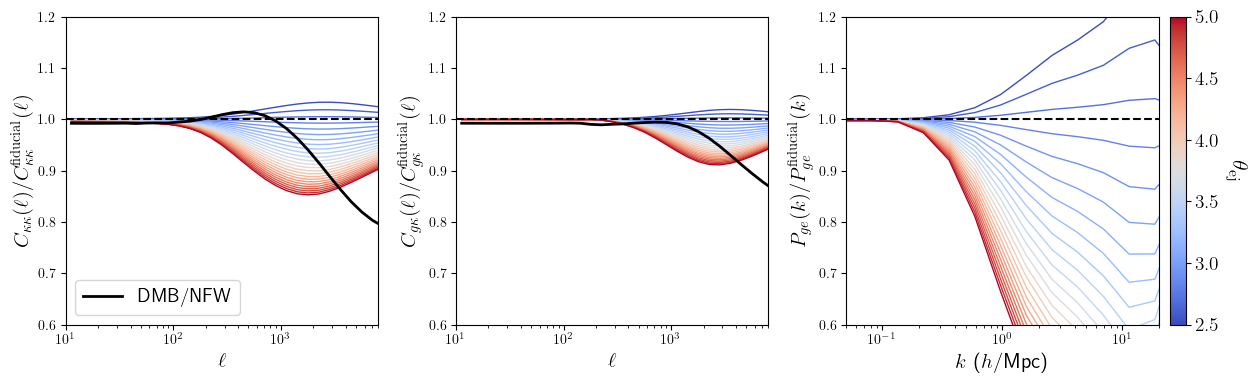

In [26]:
pl.rc('text', usetex=True)
# make a three panel plot, plotting all the theta_ej curves for for gty_out_thetaej[:,3,:], xip_out_thetaej[:,3,3,:], xim_out_thetaej[:,3,3,:]
# draw theta_ej curves from a colormap
from matplotlib import cm, colorbar
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
theta_ej_array = val_all

nell = len(ell_array)

cmap = cm.get_cmap('coolwarm')  # or any other colormap you like
# create a normalize object the scales the input Mc0 value to the range [0,1]
norm = Normalize(vmin=(theta_ej_array).min(), vmax=(theta_ej_array).max())
# analysis_dict_vary['angles_data_array'] = jnp.logspace(np.log10(0.5), np.log10(100), fac_th * len(theta_data))
# nell = 
pl.figure(figsize=(15,4))
# increase the distance between subplots:
pl.subplots_adjust(wspace=0.25)
pl.subplot(131)
for jM in tqdm(range(len(theta_ej_array))):
    color = cmap(norm((theta_ej_array[jM])))
    pl.plot(analysis_dict['l_array_survey'], Cl_sims_all[jM, 0:nell, 0]/Cl_all_fid[0:nell], color=color, alpha=1.0,lw=1.0)
pl.plot(analysis_dict['l_array_survey'], Cl_all_fid[0:nell]/Cl_all_nfw[0:nell], color='k', alpha=1.0,lw=2.0, label='DMB/NFW')
pl.axhline(1.0, color='k', ls='--')
pl.legend(fontsize=14, loc='lower left')
# pl.errorbar(analysis_dict['angles_data_array'], 1e9*gty_data_to_plot, yerr=1e9*gty_sig_to_plot, fmt='o', color='k',label='data')
# pl.text(22, 3.0, r'shear x tSZ', fontsize=13)
pl.xscale('log')
# pl.yscale('log')
pl.xlim(10,8000)
pl.ylim(0.6,1.2)
pl.ylabel(r'$C_{\kappa \kappa}(\ell)/C^{\rm fiducial}_{\kappa \kappa}(\ell)$', fontsize=15)
pl.xlabel(r'$\ell$', fontsize=15)
# pl.title('1-halo term')
pl.subplot(132)
for jM in tqdm(range(len(theta_ej_array))):
    color = cmap(norm((theta_ej_array[jM])))
    pl.plot(analysis_dict['l_array_survey'], Cl_sims_all[jM, nell:2*nell, 0]/Cl_all_fid[nell:2*nell], color=color, alpha=1.0,lw=1.0)
pl.plot(analysis_dict['l_array_survey'], Cl_all_fid[nell:2*nell]/Cl_all_nfw[nell:2*nell], color='k', alpha=1.0,lw=2.0)
pl.axhline(1.0, color='k', ls='--')
# pl.errorbar(analysis_dict['angles_data_array'], 1e4*xip_data_to_plot, yerr=1e4*xip_sig_to_plot, fmt='o', color='k',label='data')
# pl.legend()
# pl.text(18, 1.25, r'shear x shear' + '\n' + 'Component 1', fontsize=13)
pl.xscale('log')
# pl.yscale('log')
# pl.xlim(2.0,100)
# pl.ylim(0.0,1.5)
pl.xlim(10,8000)
pl.ylim(0.6,1.2)
pl.ylabel(r'$C_{g \kappa}(\ell)/C^{\rm fiducial}_{g \kappa}(\ell)$', fontsize=15)
pl.xlabel(r'$\ell$', fontsize=15)
# pl.title('2-halo term')
pl.subplot(133)
for jM in tqdm(range(len(theta_ej_array))):
    color = cmap(norm((theta_ej_array[jM])))
    pl.plot(analysis_dict['k_array_survey'], Cl_sims_all[jM, 2*nell:, 0]/Cl_all_fid[2*nell:], color=color, alpha=1.0,lw=1.0)
pl.axhline(1.0, color='k', ls='--')
# pl.errorbar(analysis_dict['angles_data_array'], 1e5*xim_data_to_plot, yerr=1e5*xim_sig_to_plot, fmt='o', color='k', label='Measurements' + '\n' + '(blinded)')
# pl.legend(loc='lower left', fontsize=13)
# pl.legend()
pl.xscale('log')
# pl.text(18, 2.75, r'shear x shear' + '\n' +'Component 2', fontsize=13)
# pl.yscale('log')
pl.xlim(0.05, 20)
pl.ylim(0.6,1.2)
# pl.ylim(0.0,3.3)
# pl.ylabel(r'$10^5 \xi_-$', fontsize=13)
pl.ylabel(r'$P_{g e}(k)/P^{\rm fiducial}_{g e}(k)$', fontsize=15)
pl.xlabel(r'$k$ ($h$/Mpc)', fontsize=15)
# pl.title('2-halo term')

# create a ScalarMappable with the colormap and norm
sm = ScalarMappable(cmap=cmap, norm=norm)
# the array is not used in this case, but normally the values used for the colormap are passed here
sm.set_array([])
# add the colorbar to the figure
cbar = pl.colorbar(sm, ax=pl.gcf().get_axes(), orientation='vertical', fraction=0.05, pad=0.01)
cbar.set_label(r'$\theta_{\rm ej}$', fontsize=16, rotation=270, labelpad=20)
cbar.ax.tick_params(labelsize=14)
pl.savefig('Cl_kk_kg_pge_thetaej2.pdf', bbox_inches='tight')




